## COL taxonomy plots - family

In [19]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken/family")

In [3]:
taxa = read.csv('otu_id_family.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<lgl>
1,49546,Flavobacteriaceae,FALSE
2,543,Enterobacteriaceae,FALSE
3,186817,Bacillaceae,FALSE
4,41297,Sphingomonadaceae,FALSE
5,41294,Nitrobacteraceae,FALSE
6,2062,Streptomycetaceae,FALSE


In [4]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")
head(taxa)

,otuid,species
,<int>,<chr>
1,49546,Flavobacteriaceae
2,543,Enterobacteriaceae
3,186817,Bacillaceae
4,41297,Sphingomonadaceae
5,41294,Nitrobacteraceae
6,2062,Streptomycetaceae


In [5]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
49546,Flavobacteriaceae
543,Enterobacteriaceae
186817,Bacillaceae
41297,Sphingomonadaceae
41294,Nitrobacteraceae
2062,Streptomycetaceae


In [6]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy) 

 chr [1:839, 1] "Flavobacteriaceae" "Enterobacteriaceae" "Bacillaceae" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:839] "49546" "543" "186817" "41297" ...
  ..$ : chr "species"


In [7]:
#read in normalized otu table
otu = read.csv('otu_normtable_family.csv',header=TRUE)
head(otu)

,X,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,49546,76960.56,35031.18,17241.17,19170.36,71075.73,28489.44,60114.19,83282.49,68911.99,⋯,47609.815,67430.369,69274.616,57837.497,35154.213,40340.594,58387.64,83548.737,80914.579,3420189
2,543,51614.30,21775.14,41500.98,101830.09,52217.16,19237.70,25080.39,23075.56,27205.92,⋯,27155.750,27799.622,25902.028,23067.143,41535.114,18996.892,31034.64,49226.632,50152.981,1892719
3,186817,51438.17,41830.63,14989.46,17941.37,49378.13,26714.57,52709.29,18957.40,59222.44,⋯,46524.008,61954.953,62787.535,45293.550,37967.783,36634.398,56478.80,45411.907,54563.246,2690423
4,41297,44457.23,101005.41,274879.63,260046.87,39774.97,144414.49,53398.38,35862.65,28649.96,⋯,2943.665,2095.095,2505.715,3620.203,8798.627,3278.632,18087.25,3356.124,1419.554,2016507
5,41294,38820.81,59660.08,95254.64,37177.10,34601.85,133161.83,51724.89,33788.32,16288.81,⋯,145667.348,17752.556,14663.928,104320.382,68557.945,256887.524,24298.43,16843.159,29617.685,2713481
6,2062,28880.76,40279.79,20660.66,21540.10,38131.58,27652.45,23111.59,68949.36,17935.06,⋯,25685.680,18691.534,21428.778,22427.736,17455.035,25329.828,24243.16,36344.117,31960.638,1584400


In [8]:
# rename first col as kingdom
names(otu)[1] <- "species"
head(otu)
dim(otu)

,species,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,49546,76960.56,35031.18,17241.17,19170.36,71075.73,28489.44,60114.19,83282.49,68911.99,⋯,47609.815,67430.369,69274.616,57837.497,35154.213,40340.594,58387.64,83548.737,80914.579,3420189
2,543,51614.30,21775.14,41500.98,101830.09,52217.16,19237.70,25080.39,23075.56,27205.92,⋯,27155.750,27799.622,25902.028,23067.143,41535.114,18996.892,31034.64,49226.632,50152.981,1892719
3,186817,51438.17,41830.63,14989.46,17941.37,49378.13,26714.57,52709.29,18957.40,59222.44,⋯,46524.008,61954.953,62787.535,45293.550,37967.783,36634.398,56478.80,45411.907,54563.246,2690423
4,41297,44457.23,101005.41,274879.63,260046.87,39774.97,144414.49,53398.38,35862.65,28649.96,⋯,2943.665,2095.095,2505.715,3620.203,8798.627,3278.632,18087.25,3356.124,1419.554,2016507
5,41294,38820.81,59660.08,95254.64,37177.10,34601.85,133161.83,51724.89,33788.32,16288.81,⋯,145667.348,17752.556,14663.928,104320.382,68557.945,256887.524,24298.43,16843.159,29617.685,2713481
6,2062,28880.76,40279.79,20660.66,21540.10,38131.58,27652.45,23111.59,68949.36,17935.06,⋯,25685.680,18691.534,21428.778,22427.736,17455.035,25329.828,24243.16,36344.117,31960.638,1584400


[1] 840  58

In [9]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,species,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,49546,76960.56,35031.18,17241.17,19170.36,71075.73,28489.44,60114.19,83282.49,68911.99,⋯,47609.815,67430.369,69274.616,57837.497,35154.213,40340.594,58387.64,83548.737,80914.579,3420189
2,543,51614.30,21775.14,41500.98,101830.09,52217.16,19237.70,25080.39,23075.56,27205.92,⋯,27155.750,27799.622,25902.028,23067.143,41535.114,18996.892,31034.64,49226.632,50152.981,1892719
3,186817,51438.17,41830.63,14989.46,17941.37,49378.13,26714.57,52709.29,18957.40,59222.44,⋯,46524.008,61954.953,62787.535,45293.550,37967.783,36634.398,56478.80,45411.907,54563.246,2690423
4,41297,44457.23,101005.41,274879.63,260046.87,39774.97,144414.49,53398.38,35862.65,28649.96,⋯,2943.665,2095.095,2505.715,3620.203,8798.627,3278.632,18087.25,3356.124,1419.554,2016507
5,41294,38820.81,59660.08,95254.64,37177.10,34601.85,133161.83,51724.89,33788.32,16288.81,⋯,145667.348,17752.556,14663.928,104320.382,68557.945,256887.524,24298.43,16843.159,29617.685,2713481
6,2062,28880.76,40279.79,20660.66,21540.10,38131.58,27652.45,23111.59,68949.36,17935.06,⋯,25685.680,18691.534,21428.778,22427.736,17455.035,25329.828,24243.16,36344.117,31960.638,1584400


In [10]:
# make the index the otus
row.names(otu_table) <- otu_table$species
otu_table$species <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
49546,76960.56,35031.18,17241.17,19170.36,71075.73,28489.44,60114.19,83282.49,68911.99,56780.51,⋯,47609.815,67430.369,69274.616,57837.497,35154.213,40340.594,58387.64,83548.737,80914.579,3420189
543,51614.30,21775.14,41500.98,101830.09,52217.16,19237.70,25080.39,23075.56,27205.92,27174.92,⋯,27155.750,27799.622,25902.028,23067.143,41535.114,18996.892,31034.64,49226.632,50152.981,1892719
186817,51438.17,41830.63,14989.46,17941.37,49378.13,26714.57,52709.29,18957.40,59222.44,54541.26,⋯,46524.008,61954.953,62787.535,45293.550,37967.783,36634.398,56478.80,45411.907,54563.246,2690423
41297,44457.23,101005.41,274879.63,260046.87,39774.97,144414.49,53398.38,35862.65,28649.96,49385.19,⋯,2943.665,2095.095,2505.715,3620.203,8798.627,3278.632,18087.25,3356.124,1419.554,2016507
41294,38820.81,59660.08,95254.64,37177.10,34601.85,133161.83,51724.89,33788.32,16288.81,22620.45,⋯,145667.348,17752.556,14663.928,104320.382,68557.945,256887.524,24298.43,16843.159,29617.685,2713481
2062,28880.76,40279.79,20660.66,21540.10,38131.58,27652.45,23111.59,68949.36,17935.06,30799.66,⋯,25685.680,18691.534,21428.778,22427.736,17455.035,25329.828,24243.16,36344.117,31960.638,1584400


In [11]:
#remove Sum column
otu_table$Sum <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
49546,76960.56,35031.18,17241.17,19170.36,71075.73,28489.44,60114.19,83282.49,68911.99,56780.51,⋯,61579.22,47609.815,67430.369,69274.616,57837.497,35154.213,40340.594,58387.64,83548.737,80914.579
543,51614.30,21775.14,41500.98,101830.09,52217.16,19237.70,25080.39,23075.56,27205.92,27174.92,⋯,37841.51,27155.750,27799.622,25902.028,23067.143,41535.114,18996.892,31034.64,49226.632,50152.981
186817,51438.17,41830.63,14989.46,17941.37,49378.13,26714.57,52709.29,18957.40,59222.44,54541.26,⋯,22299.18,46524.008,61954.953,62787.535,45293.550,37967.783,36634.398,56478.80,45411.907,54563.246
41297,44457.23,101005.41,274879.63,260046.87,39774.97,144414.49,53398.38,35862.65,28649.96,49385.19,⋯,11631.67,2943.665,2095.095,2505.715,3620.203,8798.627,3278.632,18087.25,3356.124,1419.554
41294,38820.81,59660.08,95254.64,37177.10,34601.85,133161.83,51724.89,33788.32,16288.81,22620.45,⋯,27120.00,145667.348,17752.556,14663.928,104320.382,68557.945,256887.524,24298.43,16843.159,29617.685
2062,28880.76,40279.79,20660.66,21540.10,38131.58,27652.45,23111.59,68949.36,17935.06,30799.66,⋯,41254.65,25685.680,18691.534,21428.778,22427.736,17455.035,25329.828,24243.16,36344.117,31960.638


In [12]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,170321.00,189574.00,333968.00,305941.00,209931.00,535251.00,91426.00,721196.00,351100.00,329127.00,⋯,259292.00,283660.000,170398.000,172805.000,536434.000,843768.000,521559.000,470442.00,95944.000,72558.000
49546,76960.56,35031.18,17241.17,19170.36,71075.73,28489.44,60114.19,83282.49,68911.99,56780.51,⋯,61579.22,47609.815,67430.369,69274.616,57837.497,35154.213,40340.594,58387.64,83548.737,80914.579
41294,38820.81,59660.08,95254.64,37177.10,34601.85,133161.83,51724.89,33788.32,16288.81,22620.45,⋯,27120.00,145667.348,17752.556,14663.928,104320.382,68557.945,256887.524,24298.43,16843.159,29617.685
186817,51438.17,41830.63,14989.46,17941.37,49378.13,26714.57,52709.29,18957.40,59222.44,54541.26,⋯,22299.18,46524.008,61954.953,62787.535,45293.550,37967.783,36634.398,56478.80,45411.907,54563.246
41297,44457.23,101005.41,274879.63,260046.87,39774.97,144414.49,53398.38,35862.65,28649.96,49385.19,⋯,11631.67,2943.665,2095.095,2505.715,3620.203,8798.627,3278.632,18087.25,3356.124,1419.554
543,51614.30,21775.14,41500.98,101830.09,52217.16,19237.70,25080.39,23075.56,27205.92,27174.92,⋯,37841.51,27155.750,27799.622,25902.028,23067.143,41535.114,18996.892,31034.64,49226.632,50152.981


In [13]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]
head(otus_sorted)
dim (otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
49546,76960.56,35031.18,17241.17,19170.36,71075.73,28489.44,60114.19,83282.49,68911.99,56780.51,⋯,61579.22,47609.815,67430.369,69274.616,57837.497,35154.213,40340.594,58387.64,83548.737,80914.579
41294,38820.81,59660.08,95254.64,37177.10,34601.85,133161.83,51724.89,33788.32,16288.81,22620.45,⋯,27120.00,145667.348,17752.556,14663.928,104320.382,68557.945,256887.524,24298.43,16843.159,29617.685
186817,51438.17,41830.63,14989.46,17941.37,49378.13,26714.57,52709.29,18957.40,59222.44,54541.26,⋯,22299.18,46524.008,61954.953,62787.535,45293.550,37967.783,36634.398,56478.80,45411.907,54563.246
41297,44457.23,101005.41,274879.63,260046.87,39774.97,144414.49,53398.38,35862.65,28649.96,49385.19,⋯,11631.67,2943.665,2095.095,2505.715,3620.203,8798.627,3278.632,18087.25,3356.124,1419.554
543,51614.30,21775.14,41500.98,101830.09,52217.16,19237.70,25080.39,23075.56,27205.92,27174.92,⋯,37841.51,27155.750,27799.622,25902.028,23067.143,41535.114,18996.892,31034.64,49226.632,50152.981
2062,28880.76,40279.79,20660.66,21540.10,38131.58,27652.45,23111.59,68949.36,17935.06,30799.66,⋯,41254.65,25685.680,18691.534,21428.778,22427.736,17455.035,25329.828,24243.16,36344.117,31960.638


[1] 839  56

In [14]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
49546,76960.56,35031.18,17241.17,19170.36,71075.73,28489.44,60114.19,83282.49,68911.99,56780.51,⋯,61579.22,47609.815,67430.369,69274.616,57837.497,35154.213,40340.594,58387.64,83548.737,80914.579
41294,38820.81,59660.08,95254.64,37177.10,34601.85,133161.83,51724.89,33788.32,16288.81,22620.45,⋯,27120.00,145667.348,17752.556,14663.928,104320.382,68557.945,256887.524,24298.43,16843.159,29617.685
186817,51438.17,41830.63,14989.46,17941.37,49378.13,26714.57,52709.29,18957.40,59222.44,54541.26,⋯,22299.18,46524.008,61954.953,62787.535,45293.550,37967.783,36634.398,56478.80,45411.907,54563.246
41297,44457.23,101005.41,274879.63,260046.87,39774.97,144414.49,53398.38,35862.65,28649.96,49385.19,⋯,11631.67,2943.665,2095.095,2505.715,3620.203,8798.627,3278.632,18087.25,3356.124,1419.554
543,51614.30,21775.14,41500.98,101830.09,52217.16,19237.70,25080.39,23075.56,27205.92,27174.92,⋯,37841.51,27155.750,27799.622,25902.028,23067.143,41535.114,18996.892,31034.64,49226.632,50152.981
2062,28880.76,40279.79,20660.66,21540.10,38131.58,27652.45,23111.59,68949.36,17935.06,30799.66,⋯,41254.65,25685.680,18691.534,21428.778,22427.736,17455.035,25329.828,24243.16,36344.117,31960.638


In [15]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken/COL_metadata_012025.csv', header=TRUE)
head(metadata)

,SampleID,Transect,CollectionDate,Year,Tag_num,Tag_ID,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,O_21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
2,032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,O_22,OFAV,Healthy,Healthy,,,
3,032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,O_23,OFAV,Healthy,Healthy,,,
4,032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,O_29,OFAV,Healthy,Healthy,,,
5,032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,O_37,OFAV,Healthy,Healthy,,,
6,012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,O_37,OFAV,Healthy,Healthy,Y-2025,,


In [16]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
head(metadata)

,Transect,CollectionDate,Year,Tag_num,Tag_ID,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,O_21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,O_22,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,O_23,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,O_29,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,O_37,OFAV,Healthy,Healthy,,,
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,O_37,OFAV,Healthy,Healthy,Y-2025,,


In [17]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(metadata)

In [46]:
# Create phyloseq object
COL_f_all = phyloseq(OTU, SAMP, TAX)
COL_f_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 839 taxa and 56 samples ]
sample_data() Sample Data:       [ 56 samples by 11 sample variables ]
tax_table()   Taxonomy Table:    [ 839 taxa by 1 taxonomic ranks ]

In [20]:
#order of facets - might not need because want to facet by species
sample_data(COL_f_all)$Species_o <- factor(sample_data(COL_f_all)$Species, 
                                      levels = c("OFAV", "MCAV", "DLAB", "PSTR"))

In [21]:
options(repr.plot.width=15, repr.plot.height=15)

In [21]:
#install.packages("viridis")
#install.packages("pals")

In [22]:
library(viridis)
library(pals)

Loading required package: viridisLite


Attaching package: ‘pals’


The following objects are masked from ‘package:viridis’:

    cividis, inferno, magma, plasma, turbo, viridis


The following objects are masked from ‘package:viridisLite’:

    cividis, inferno, magma, plasma, turbo, viridis




In [23]:
COL_f_all = prune_taxa(names(sort(taxa_sums(COL_f_all),TRUE)[1:50]), COL_f_all)

In [24]:
sample_data(COL_f_all)$Year_o <- factor(sample_data(COL_f_all)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

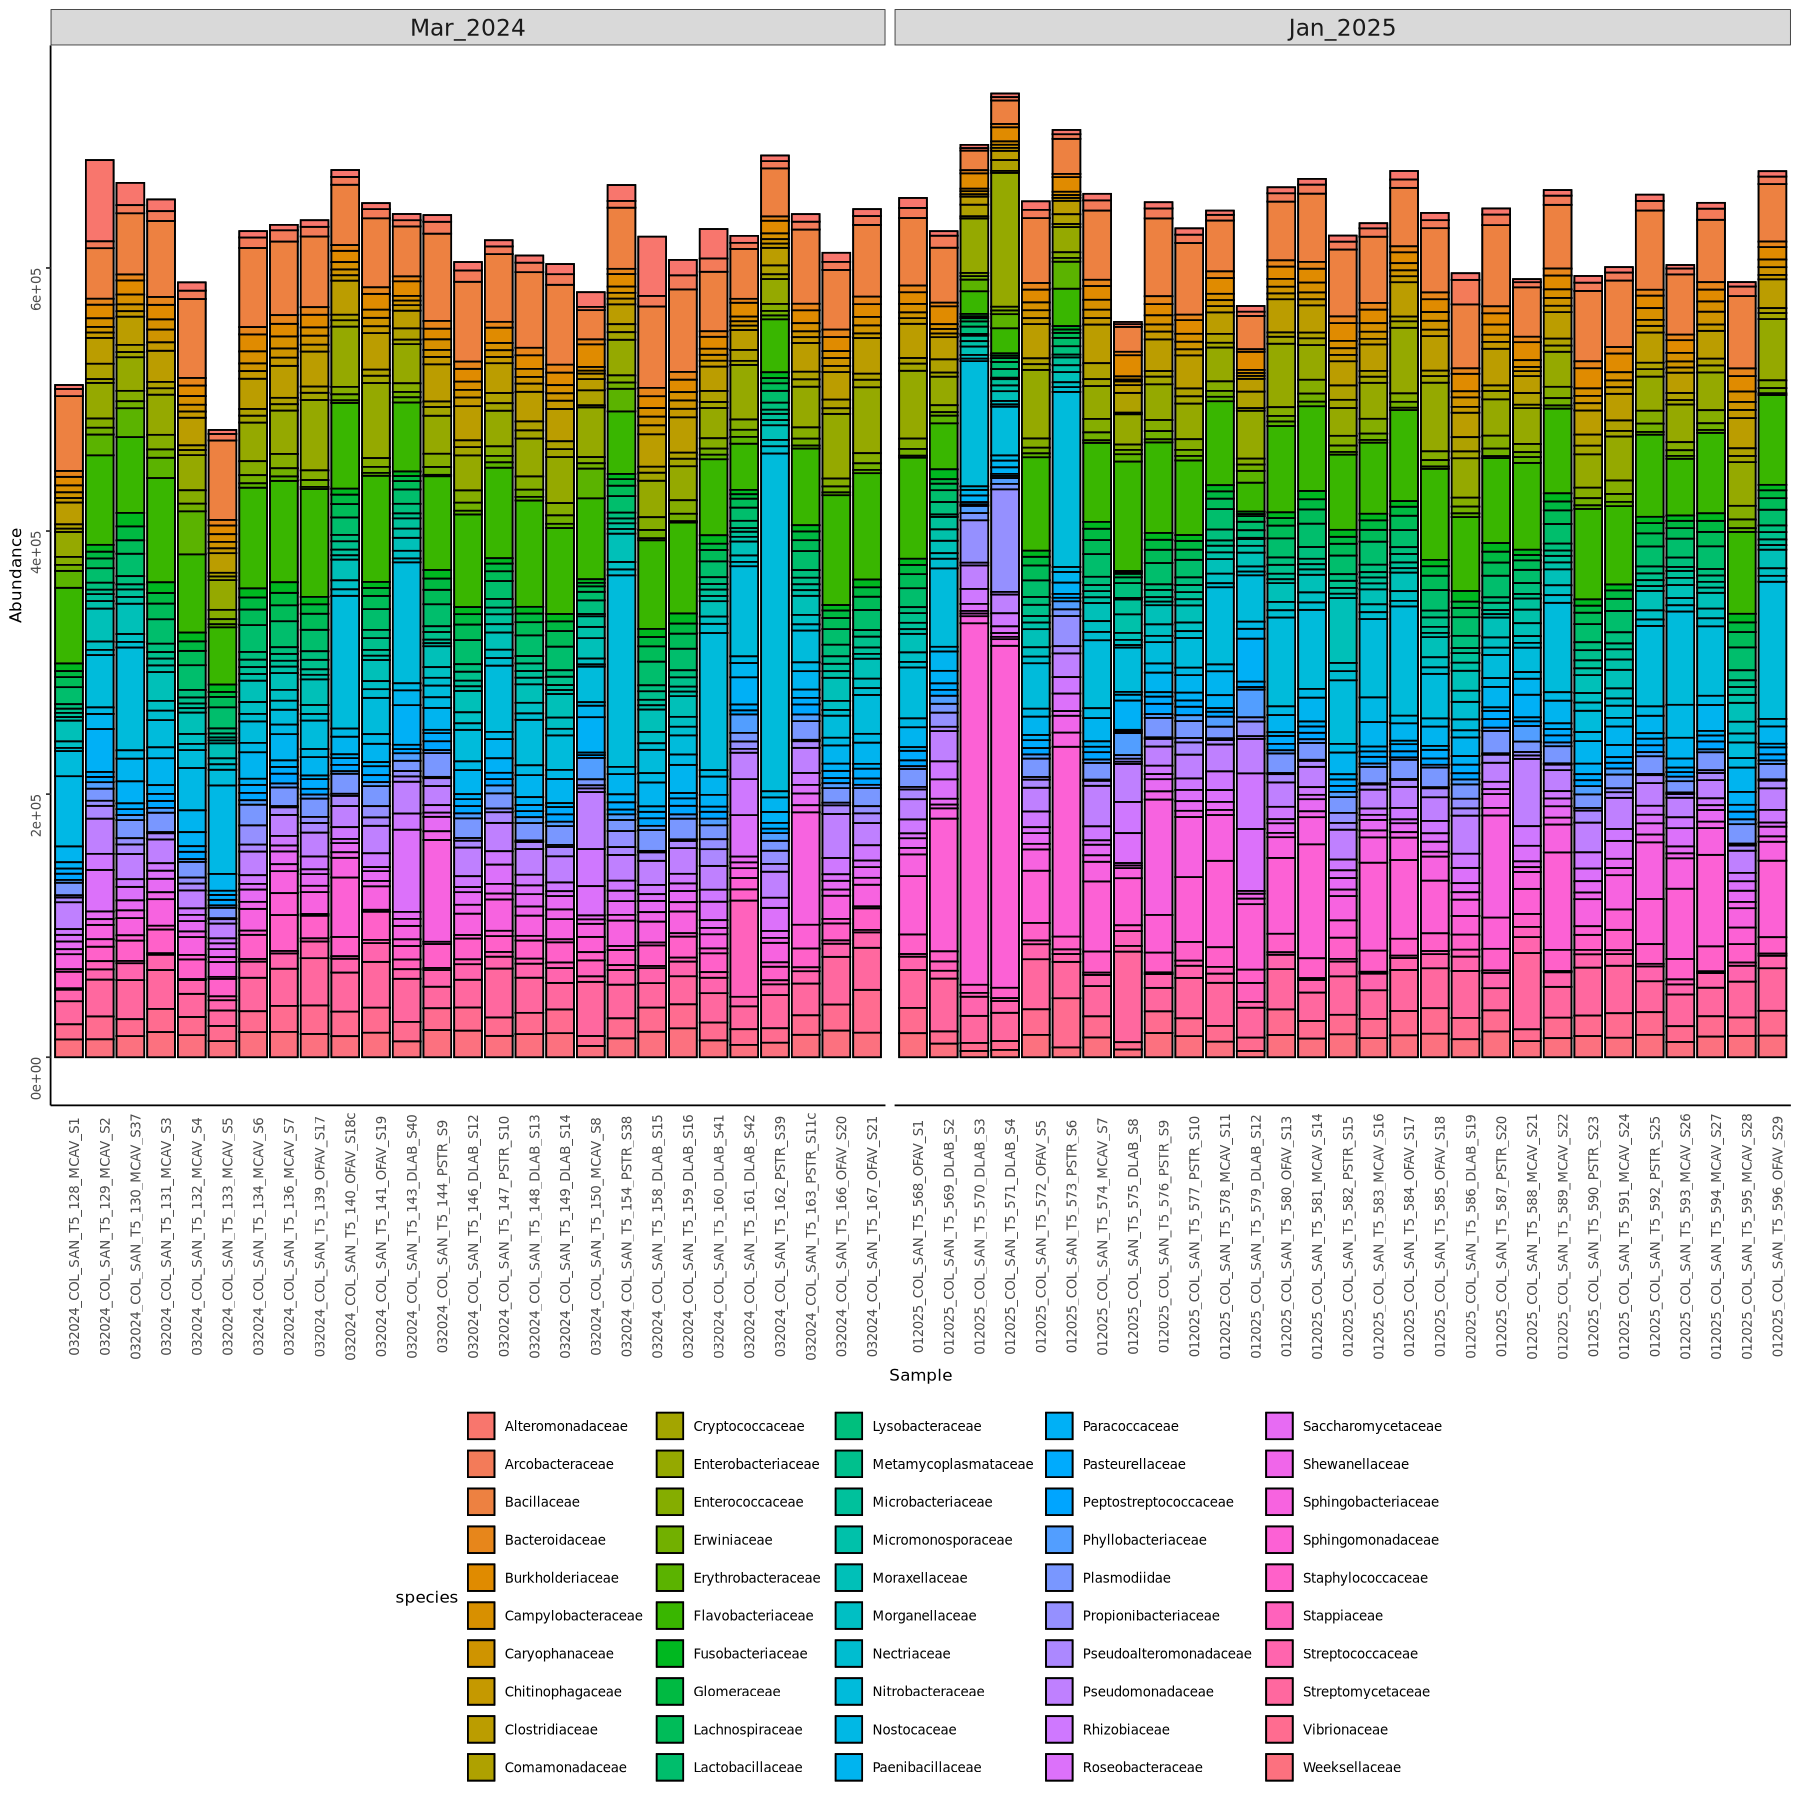

In [26]:
#taxa plot top 50 families
COL_f_all_50_plot<-plot_bar(COL_f_all,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
#scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10))
COL_f_all_50_plot

In [27]:
#save with the hideous colors for now but find new palette pronto
ggsave(filename = "taxonomy_family_50.png", plot = COL_f_all_50_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [25]:
#https://rampgenerator.com/
colors_50 <- c("#4477AA",
  "#4881B2",
  "#4C8CBB",
  "#5096C3",
  "#55A1CB",
  "#59ABD4",
  "#5DB5DC",
  "#61C0E4",
  "#65CAED",
  "#5FC5DB",
  "#57BDC4",
  "#4EB4AD",
  "#46AC96",
  "#3EA47F",
  "#359B68",
  "#2D9352",
  "#258B3B",
  "#308C34",
  "#459236",
  "#5A9939",
  "#6E9F3B",
  "#83A53D",
  "#98AB3F",
  "#ADB241",
  "#C2B843",
  "#CEB647",
  "#D2AB4D",
  "#D6A154",
  "#DB975A",
  "#DF8C60",
  "#E38266",
  "#E7776D",
  "#EB6D73",
  "#EB6477",
  "#E35E77",
  "#DB5777",
  "#D25177",
  "#CA4B77",
  "#C24577",
  "#B93E77",
  "#B13877",
  "#AA3678",
  "#AC4681",
  "#AF5789",
  "#B16891",
  "#B3789A",
  "#B589A2",
  "#B79AAA",
  "#B9AAB3",
  "#BBBBBB")

In [26]:
#shuffle colors
set.seed(123)
shuffled_colors_50 <- sample(colors_50)

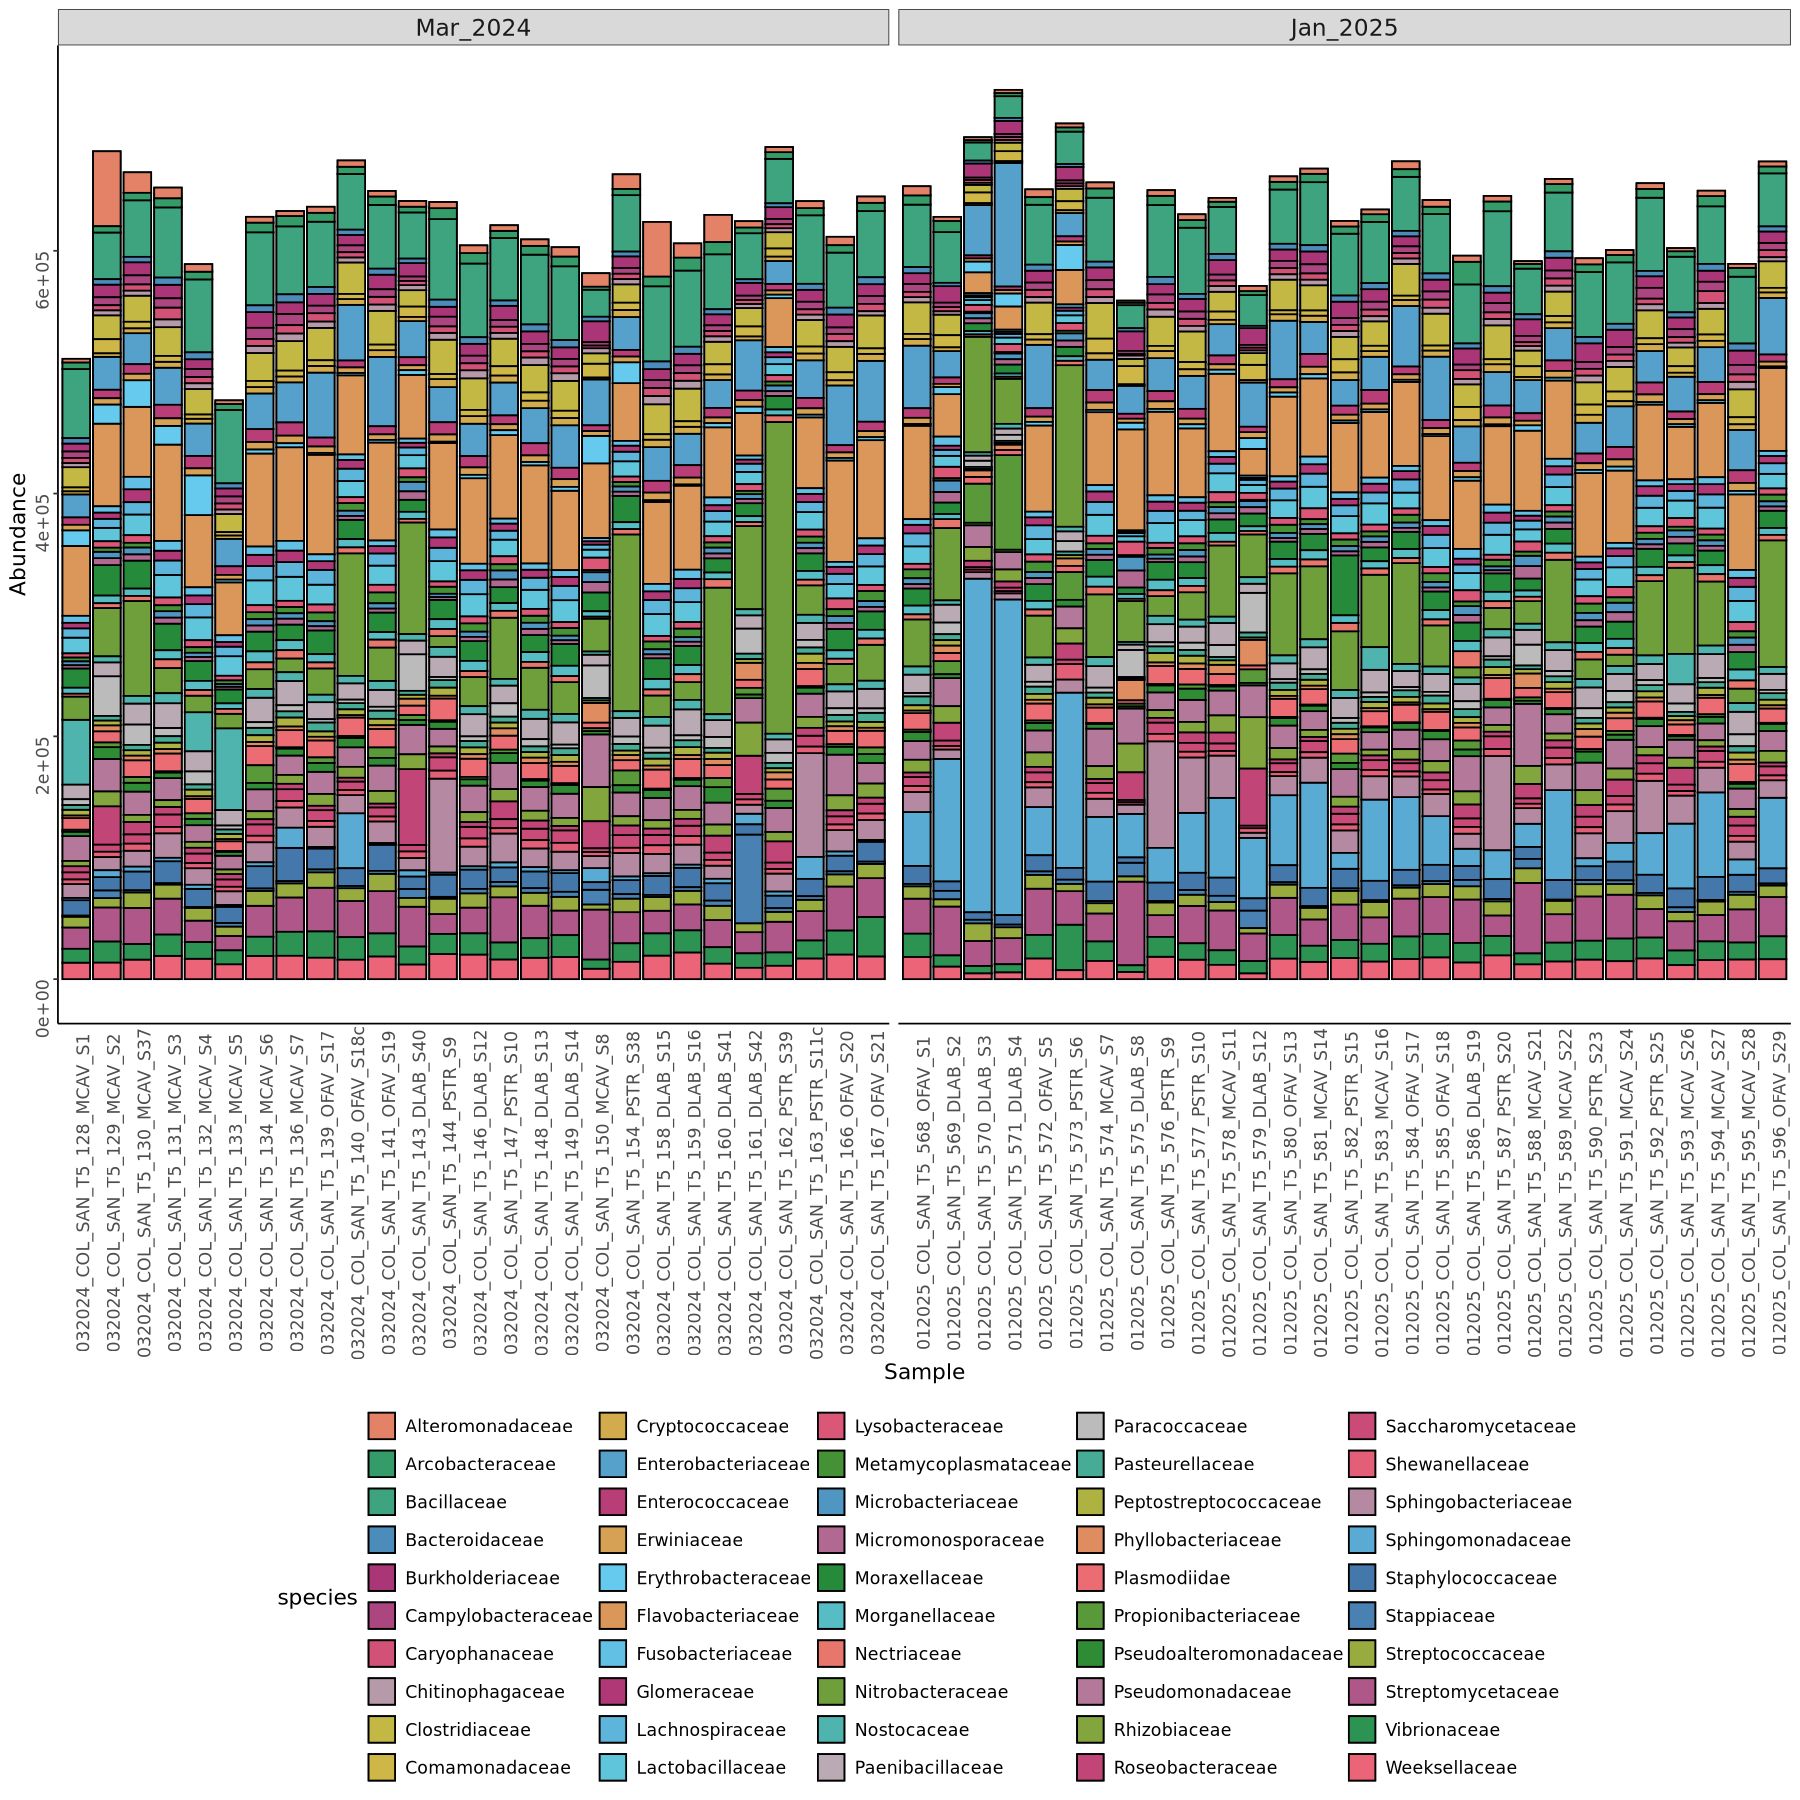

In [37]:
#taxa plot top 50 families
COL_f_all_50_plot<-plot_bar(COL_f_all,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=13))
COL_f_all_50_plot

In [30]:
#save with the hideous colors for now but find new palette pronto
ggsave(filename = "taxonomy_family_50.png", plot = COL_f_all_50_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [31]:
sample_data(COL_f_all)$Species_o <- factor(sample_data(COL_f_all)$Species, 
                                      levels = c("OFAV", "MCAV","DLAB","PSTR"))

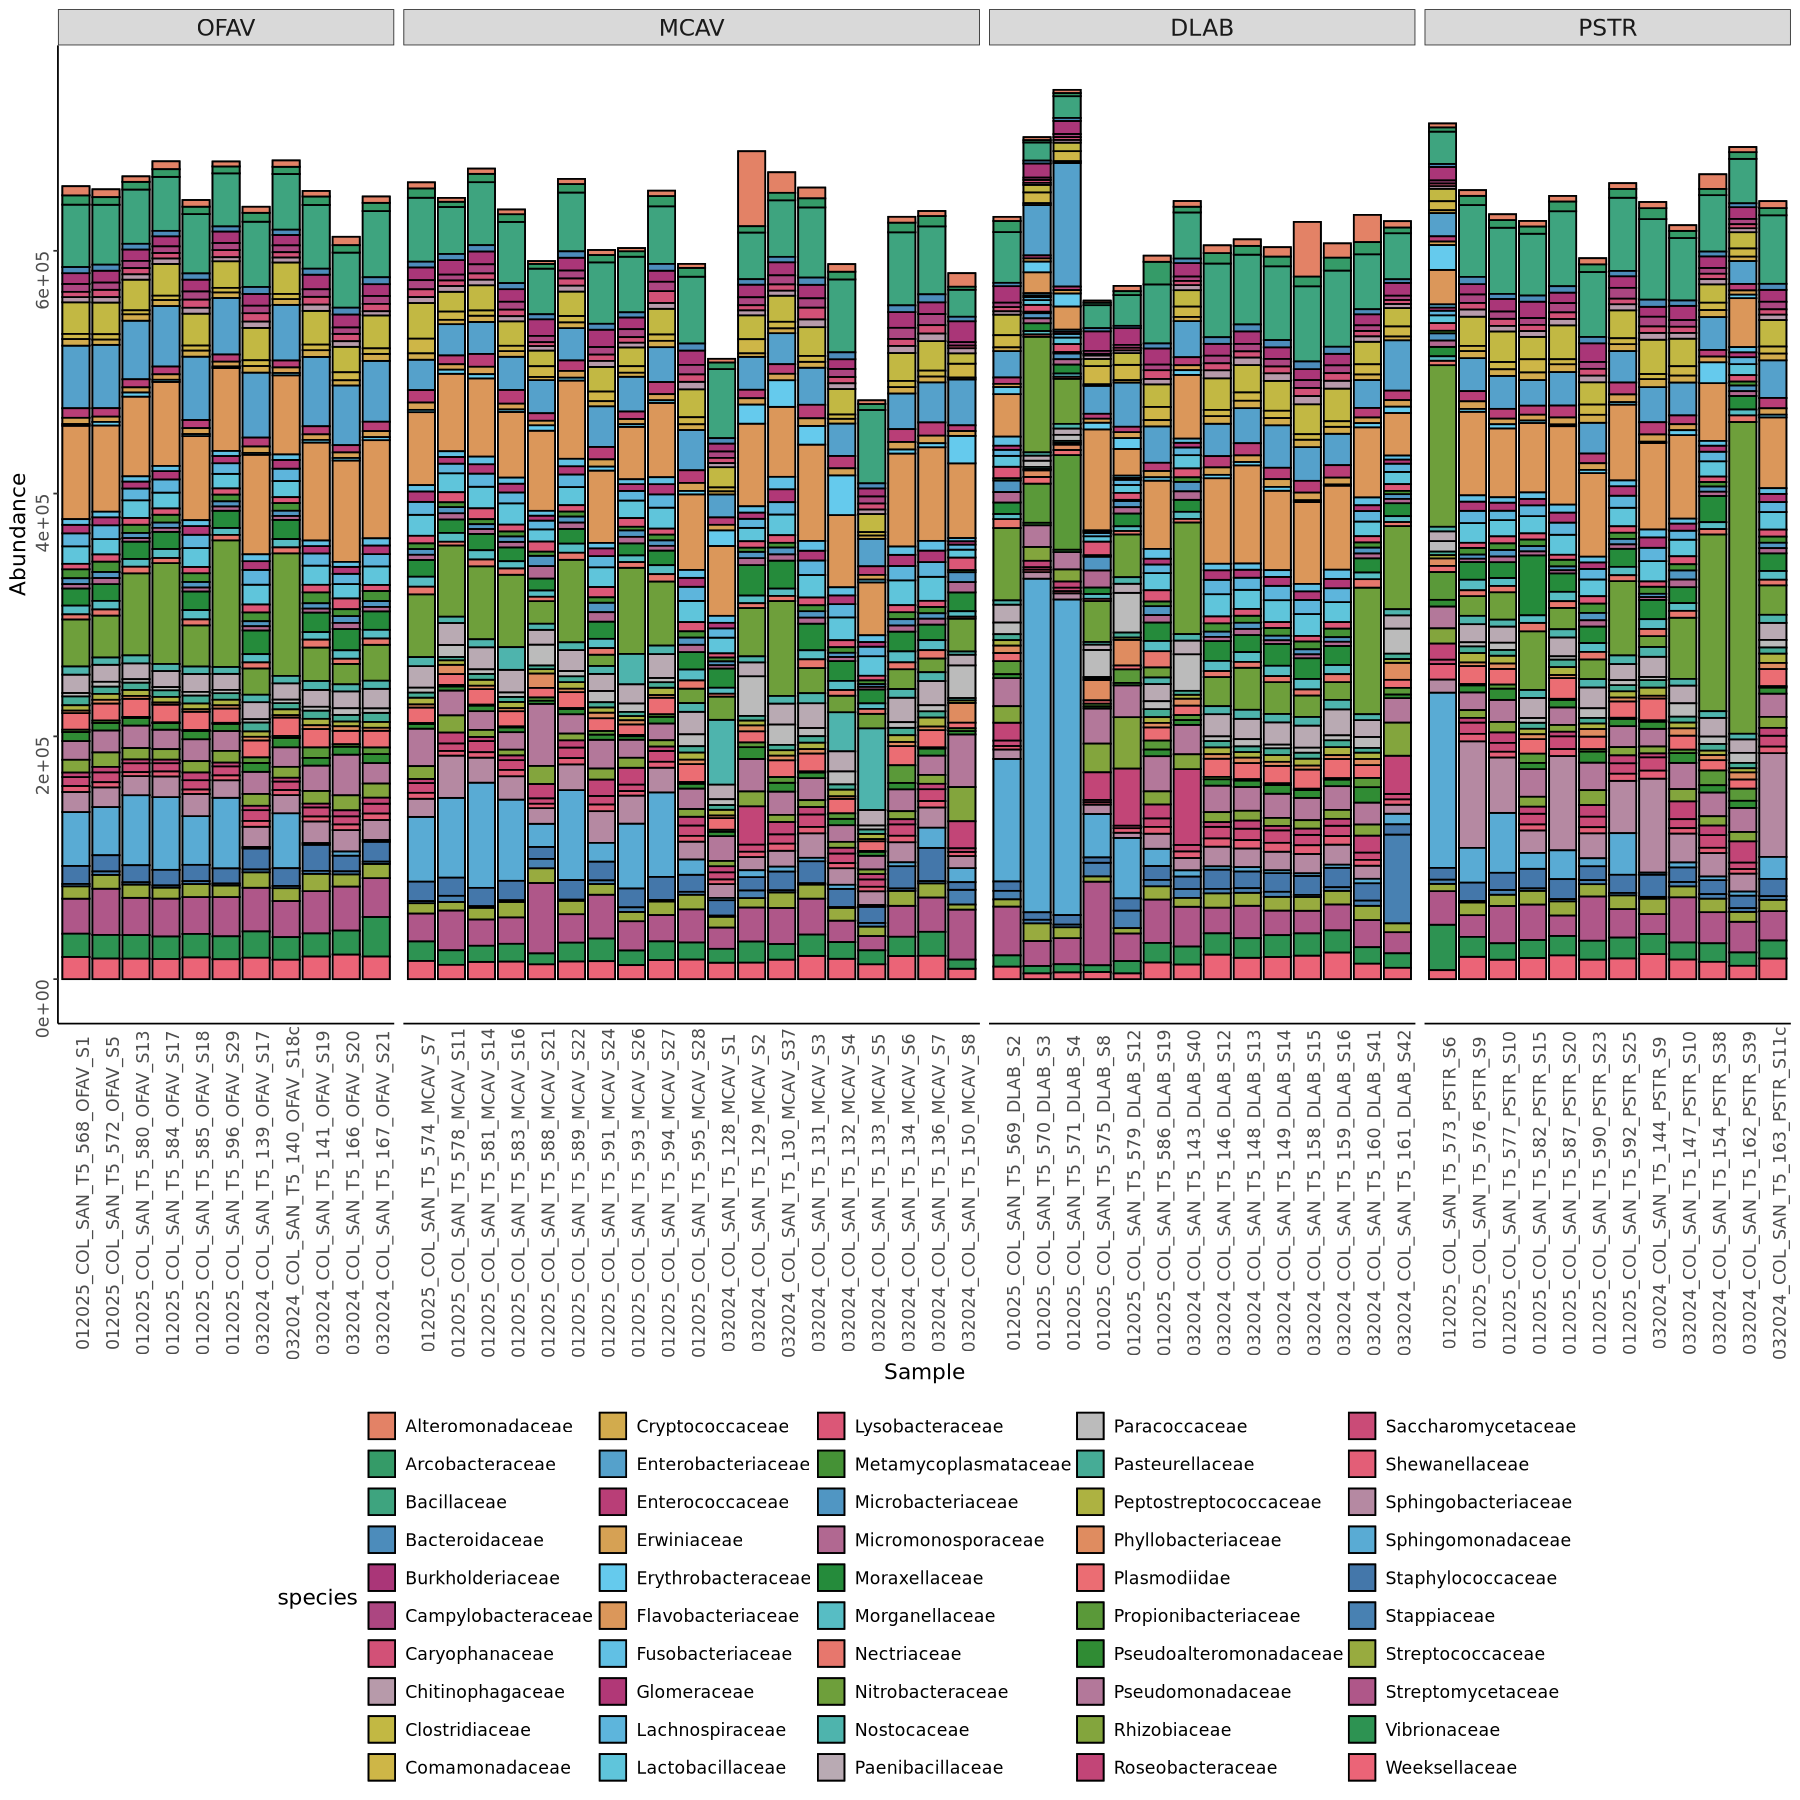

In [33]:
#taxa plot top 50 families
COL_f_all_50_plot_sp<-plot_bar(COL_f_all,fill='species')+
facet_grid(~Species_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=13))
COL_f_all_50_plot_sp

In [34]:
ggsave(filename = "taxonomy_family_50_sp.png", plot = COL_f_all_50_plot_sp, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [35]:
#remove samples
to_remove <- c("012025_COL_SAN_T5_570_DLAB_S3", "012025_COL_SAN_T5_571_DLAB_S4", "032024_COL_SAN_T5_154_PSTR_S38")

In [47]:
COL_f_all_clean <- prune_samples(!(sample_names(COL_f_all) %in% to_remove), COL_f_all)

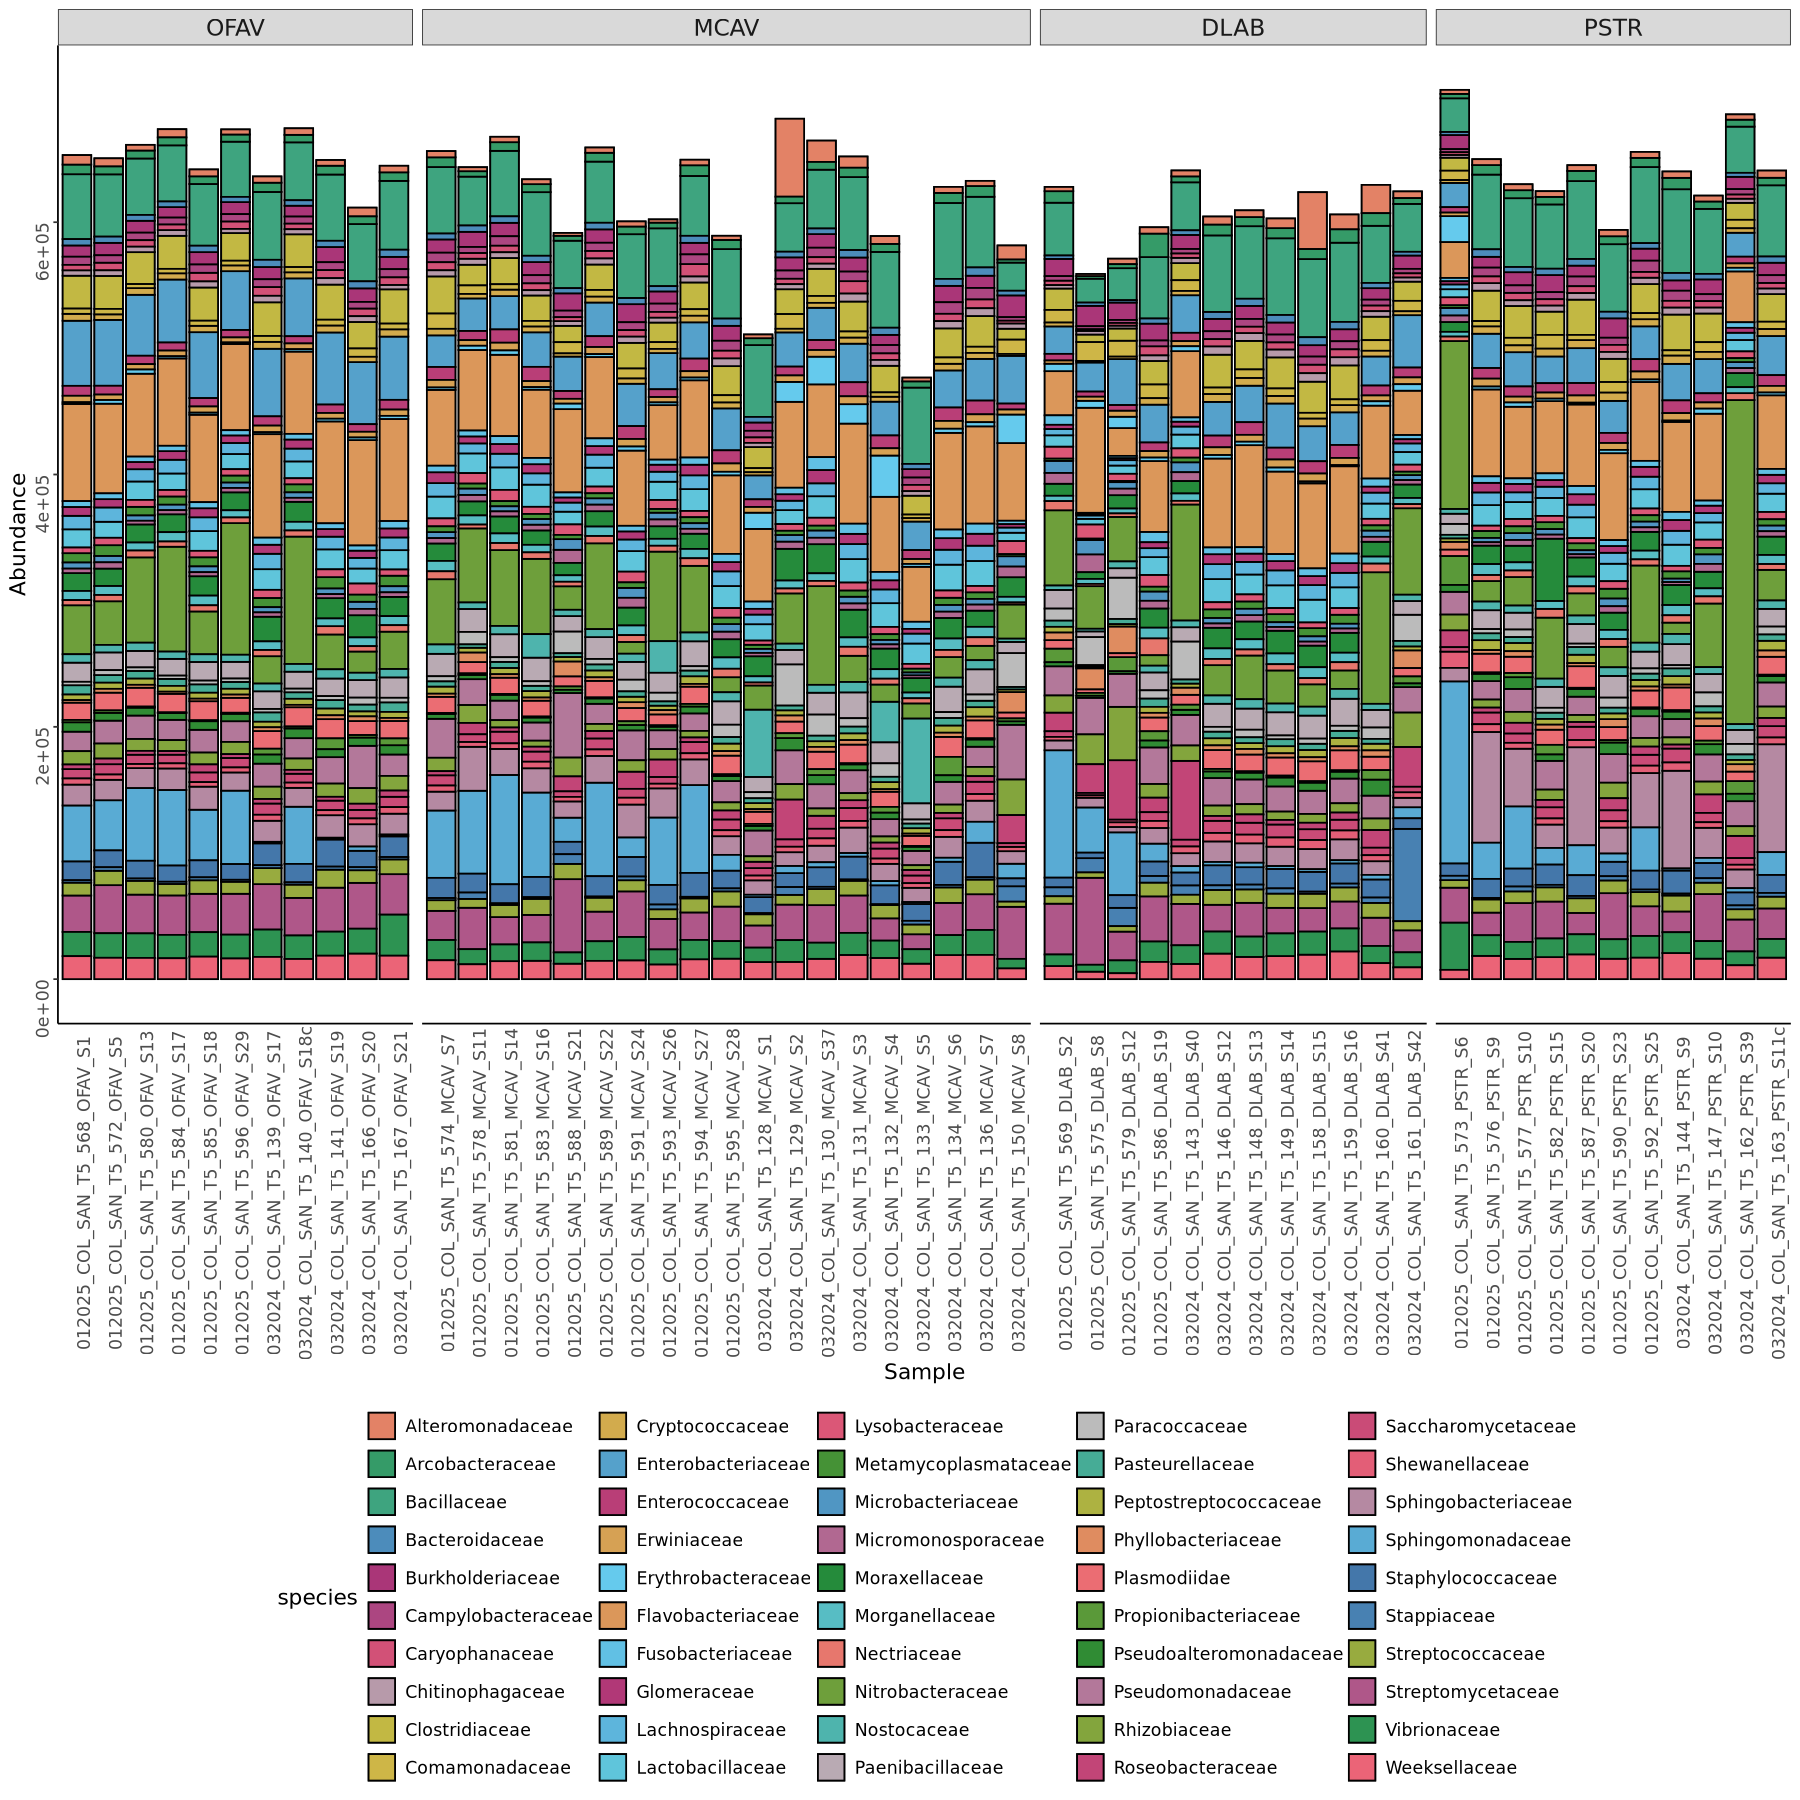

In [38]:
#taxa plot top 50 families with a few samples removed
COL_f_all_50_plot_sp1<-plot_bar(COL_f_all_clean,fill='species')+
facet_grid(~Species_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=13))
COL_f_all_50_plot_sp1

In [39]:
ggsave(filename = "taxonomy_family_50_sp_clean.png", plot = COL_f_all_50_plot_sp1, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

#### do separately for each coral species

##### MCAV

In [48]:
#make sure to take from the original phyloseq object, not the pruned to 50 taxa
COL_mcav <- subset_samples(COL_f_all_clean, Species == "MCAV")
COL_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 839 taxa and 19 samples ]
sample_data() Sample Data:       [ 19 samples by 11 sample variables ]
tax_table()   Taxonomy Table:    [ 839 taxa by 1 taxonomic ranks ]

In [49]:
#now prune
COL_mcav_50 = prune_taxa(names(sort(taxa_sums(COL_mcav),TRUE)[1:50]), COL_mcav)

In [50]:
#now do by indiv colony
sample_data(COL_mcav_50)$Tag_m <- factor(sample_data(COL_mcav_50)$Tag_ID, 
                                      levels = c("M_2","M_5", "M_6", "M_7", "M_8", "M_9", "M_10", "M_13", "M_14", "M_3"))

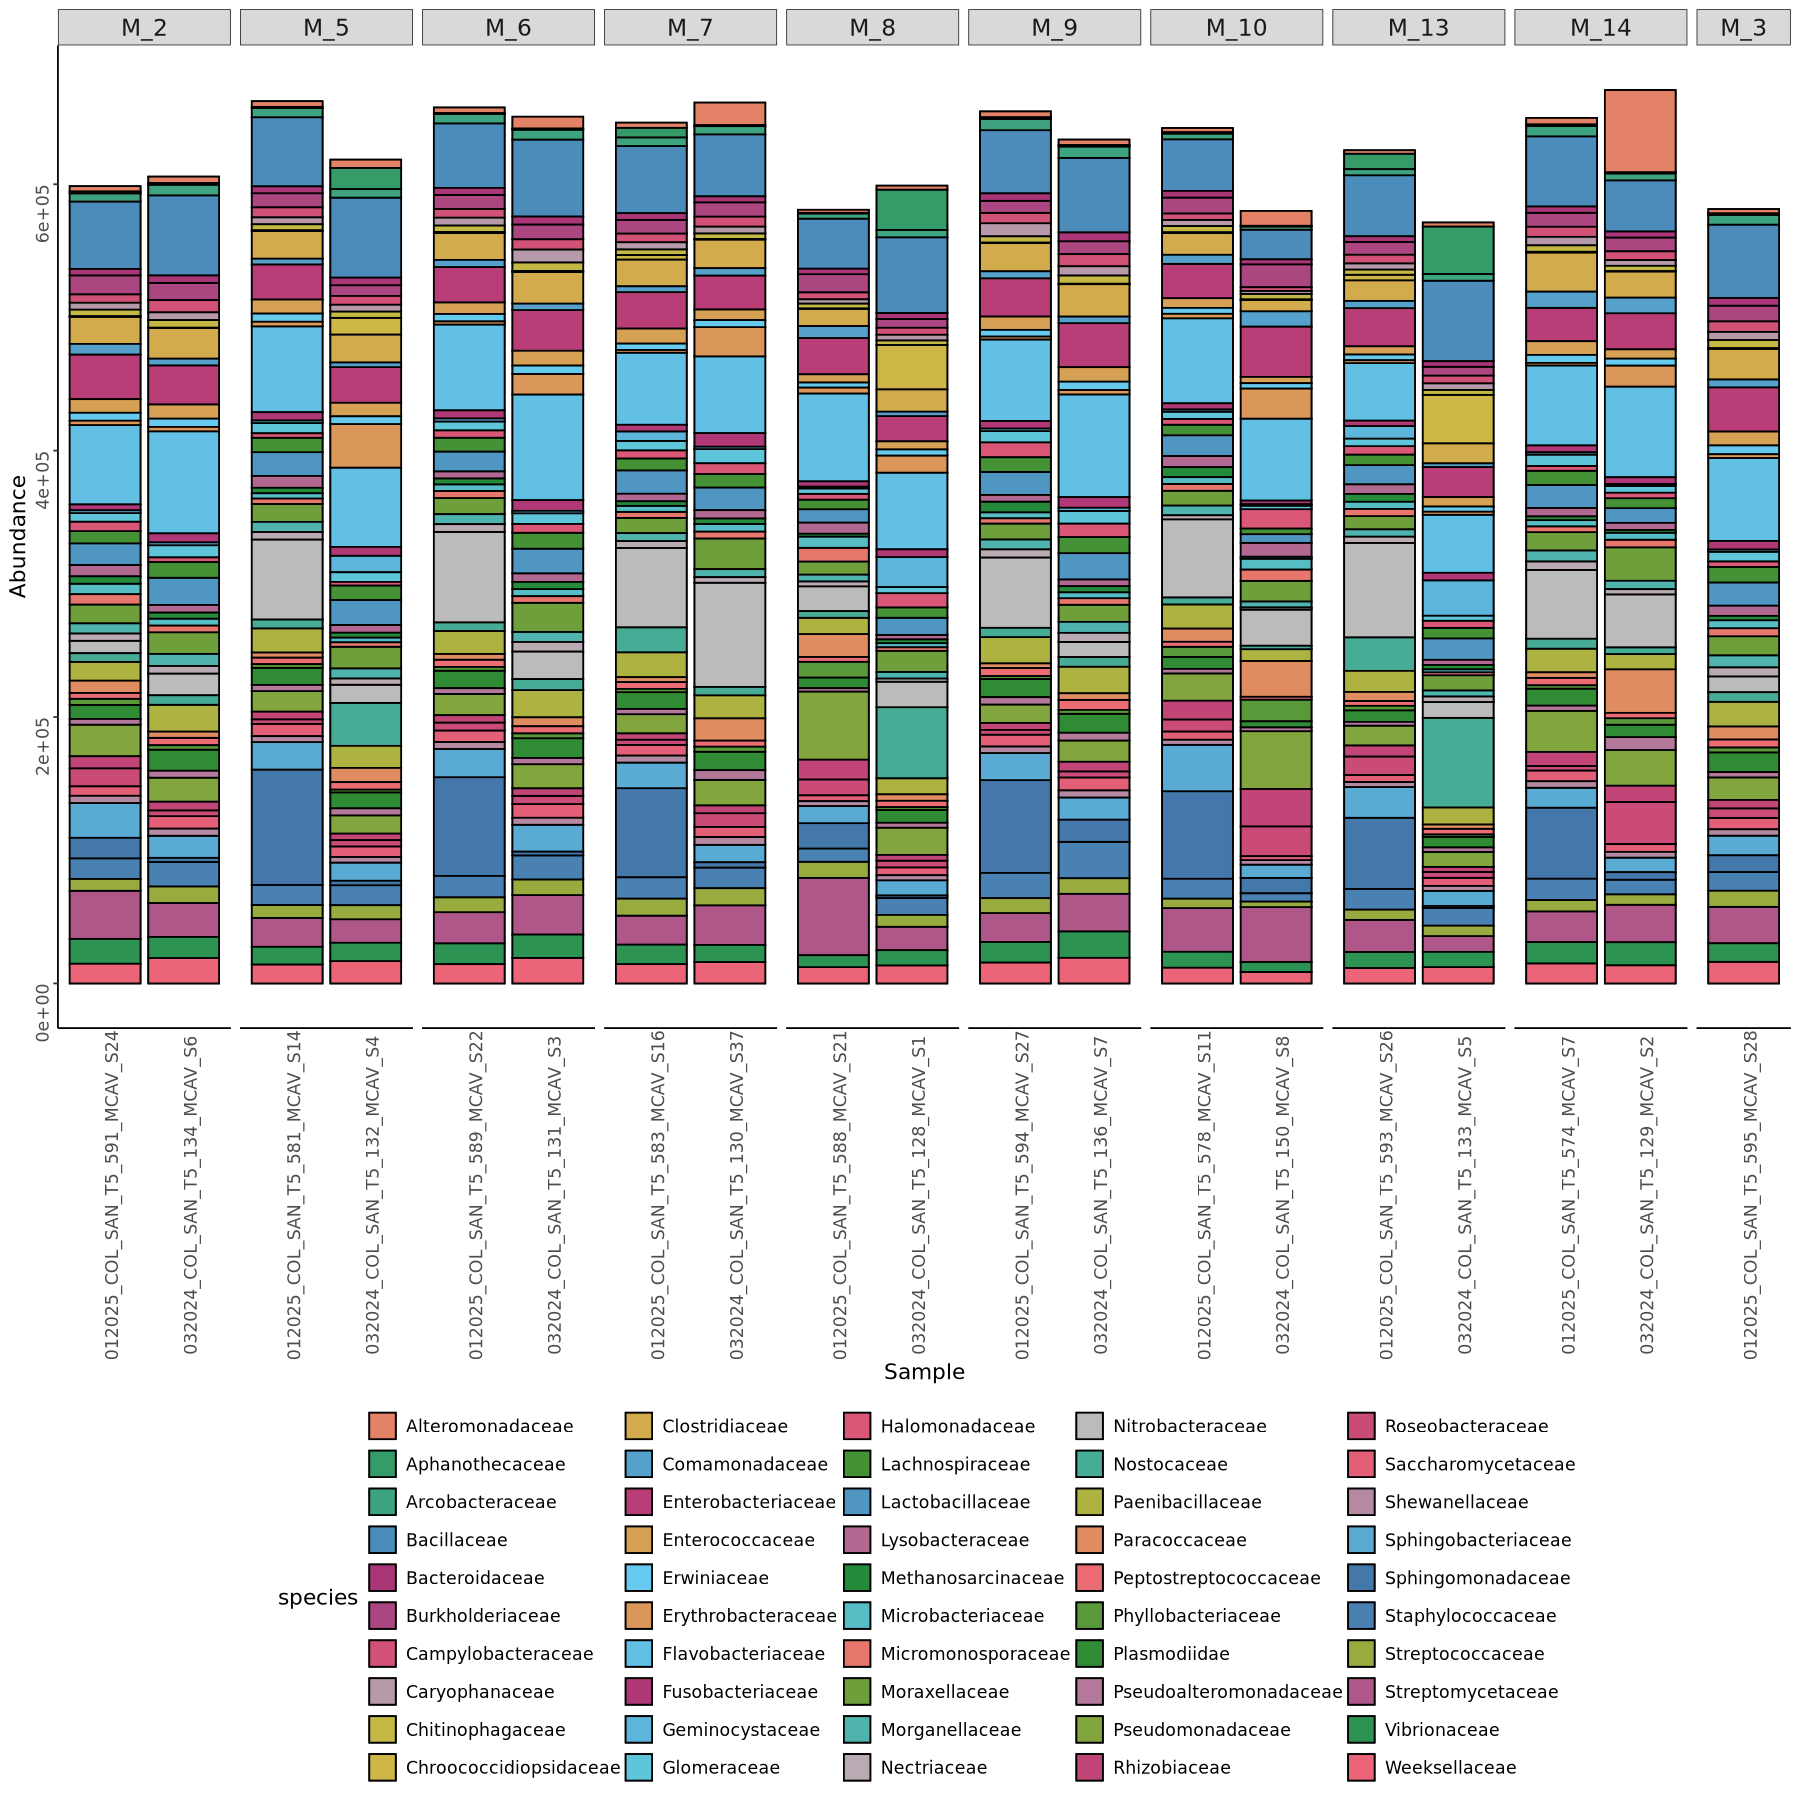

In [51]:
#taxa plot top 50 families in MCAV
COL_mcav_plot<-plot_bar(COL_mcav_50,fill='species')+
facet_grid(~Tag_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=13))
COL_mcav_plot

In [52]:
ggsave(filename = "mcav_family_50.png", plot = COL_mcav_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

##### DLAB

In [53]:
COL_dlab <- subset_samples(COL_f_all_clean, Species == "DLAB")
COL_dlab

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 839 taxa and 12 samples ]
sample_data() Sample Data:       [ 12 samples by 11 sample variables ]
tax_table()   Taxonomy Table:    [ 839 taxa by 1 taxonomic ranks ]

In [54]:
#now prune
COL_dlab_50 = prune_taxa(names(sort(taxa_sums(COL_dlab),TRUE)[1:50]), COL_dlab)

In [59]:
#order of facets by colony
sample_data(COL_dlab_50)$Tag_d <- factor(sample_data(COL_dlab_50)$Tag_ID, 
                                      levels = c("D_81", "D_86", "D_94", "D_99", "D_83","D_87" , "D_88", "D_100"))

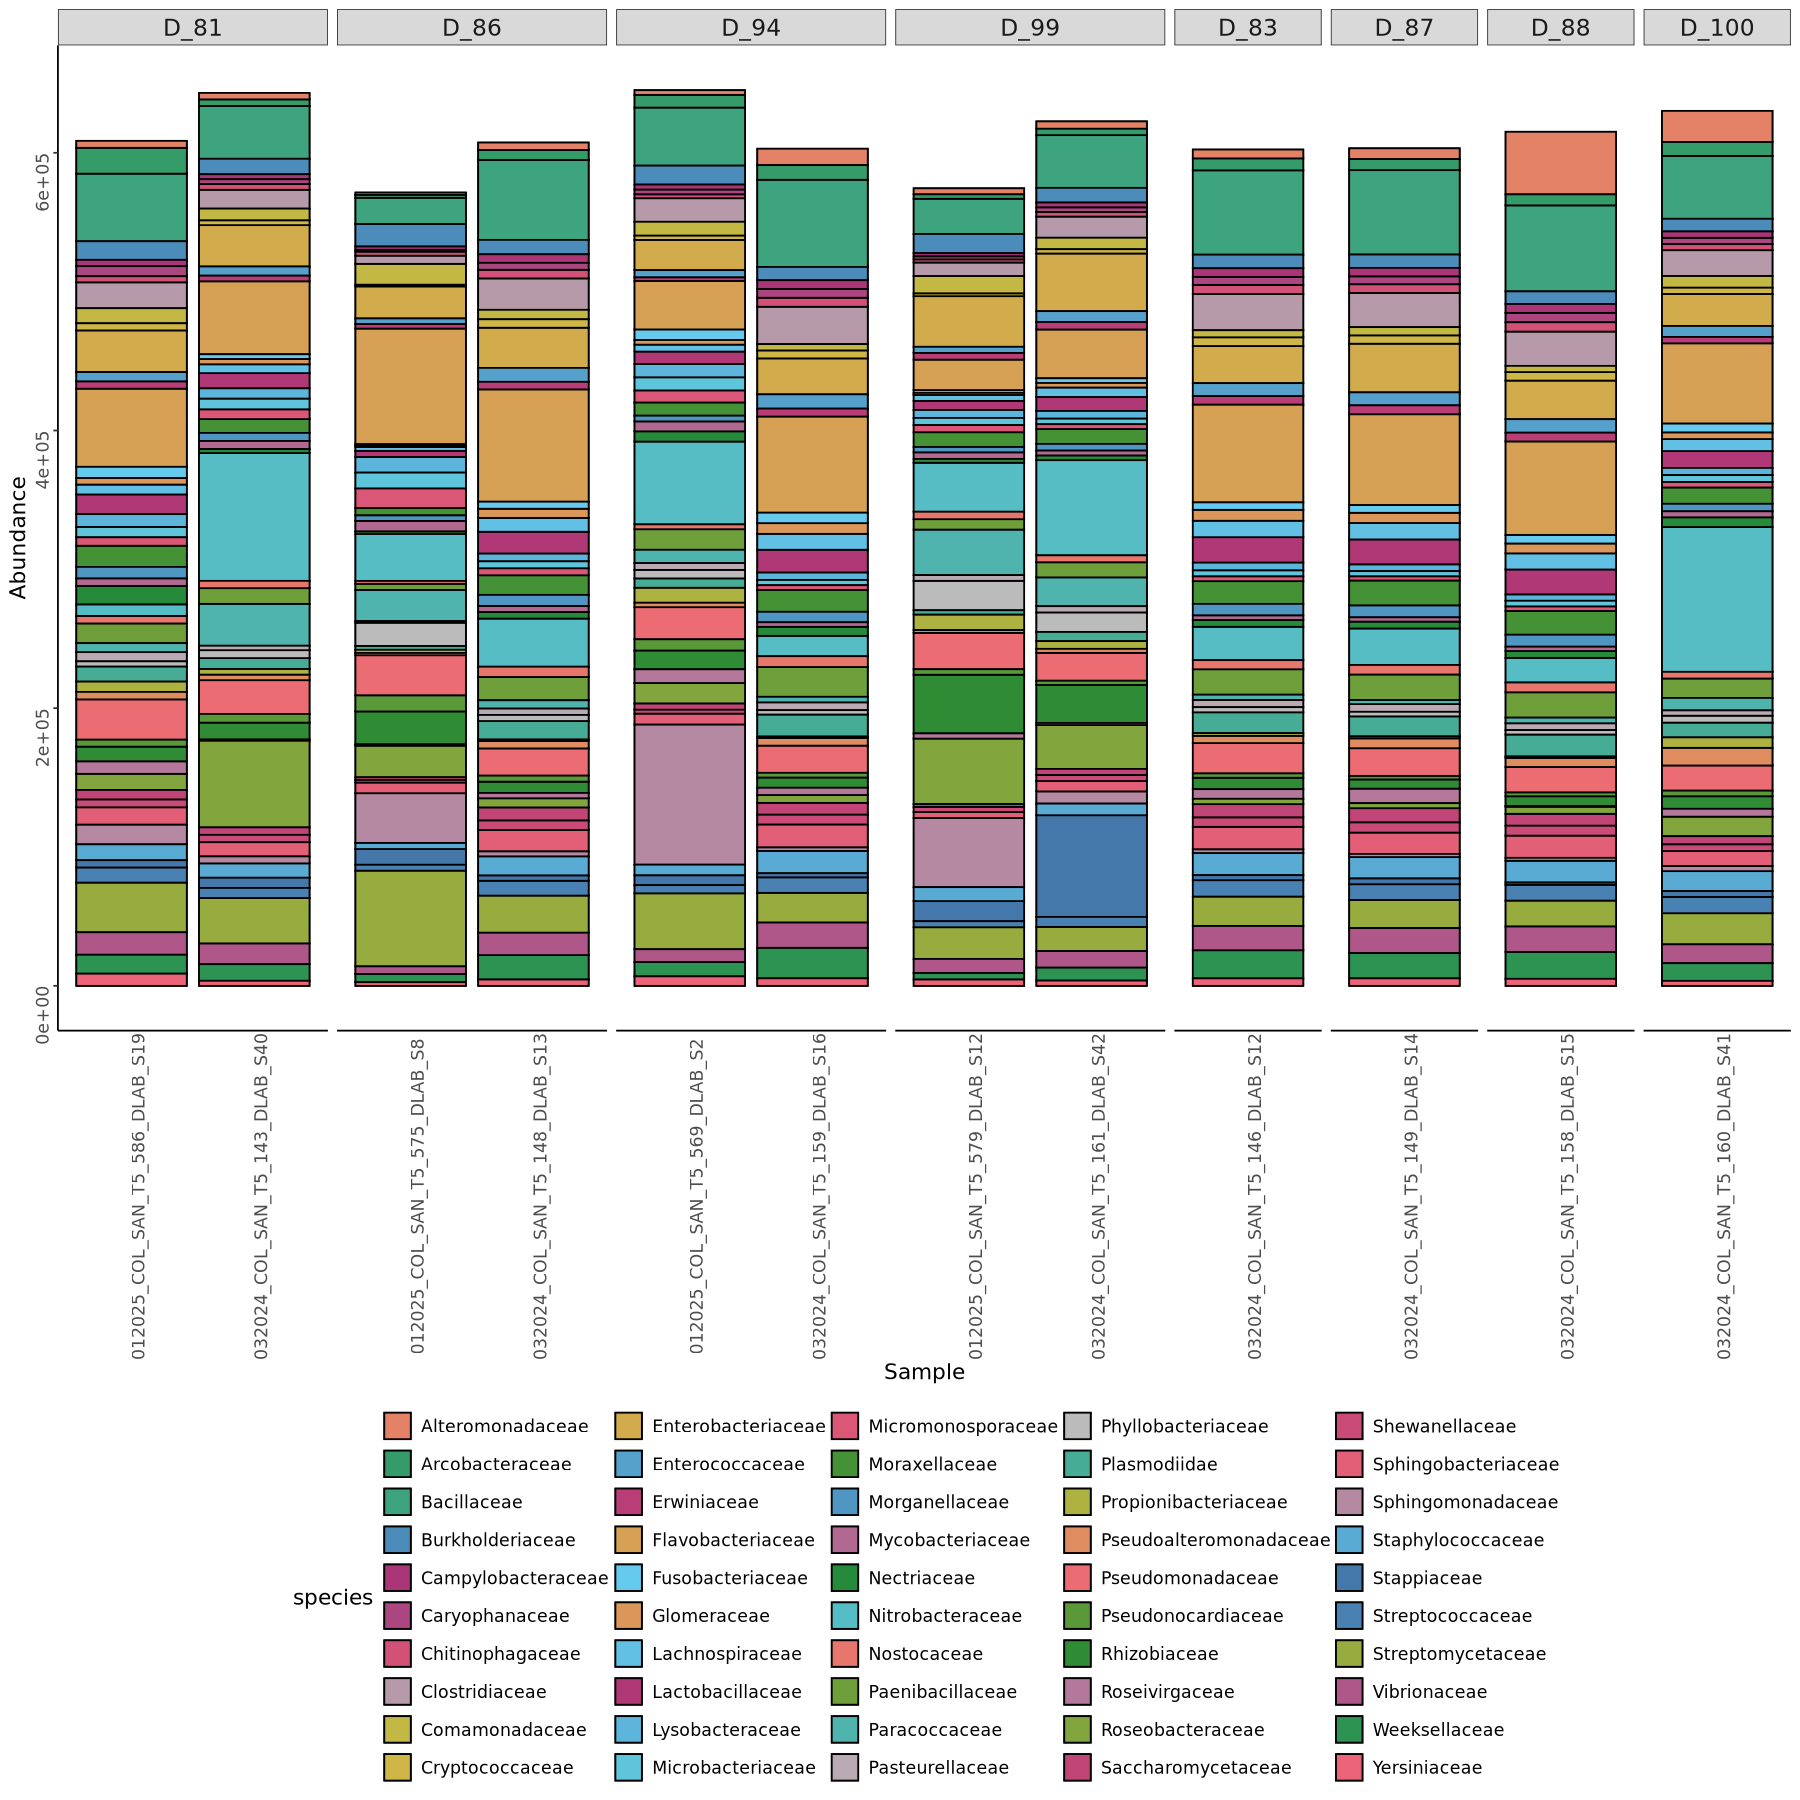

In [60]:
#taxa plot top 50 families in DLAB
COL_dlab_plot<-plot_bar(COL_dlab_50,fill='species')+
facet_grid(~Tag_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=13))
COL_dlab_plot

In [61]:
ggsave(filename = "dlab_family_50.png", plot = COL_dlab_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)